use multiple records: 100, 101, 103, 105, 109, 111, 112, 113, 115, 117 

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import (plot_acf)
from statsmodels.stats.diagnostic import (acorr_ljungbox)
import shap
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Selected MIT-BIH records
records = [
    '100',
    '101',
    '103',
    '105',
    '109',
    '111',
    '112',
    '113',
    '115',
    '117'
]

# ECG sampling frequency
fs = 360

# Sliding window size
window_size = 5

# Store all processed samples
all_X = []
all_y = []

In [5]:
all_hr = []

for record_id in records:

    print(f"Processing Record {record_id}")

    # Load ECG
    record = wfdb.rdrecord(
        record_id,
        pn_dir='mitdb'
    )

    # Load annotations
    annotation = wfdb.rdann(
        record_id,
        'atr',
        pn_dir='mitdb'
    )

Processing Record 100
Processing Record 101
Processing Record 103
Processing Record 105
Processing Record 109
Processing Record 111
Processing Record 112
Processing Record 113
Processing Record 115
Processing Record 117


R peaks

In [6]:
r_peaks = annotation.sample

RR intervals

In [7]:
rr_intervals = np.diff(r_peaks) / fs

Heart rate

In [8]:
heart_rate = 60 / rr_intervals

DataFrame

In [9]:
df = pd.DataFrame({
    'heart_rate': heart_rate
})

Outlier filtering

In [10]:
df['heart_rate'] = df['heart_rate'].where(
    (df['heart_rate'] >= 40) &
    (df['heart_rate'] <= 180)
)

Interpolation

In [11]:
df['heart_rate'] = (
    df['heart_rate']
    .interpolate()
)

Smoothing

In [12]:
df['heart_rate'] = (
    df['heart_rate']
    .rolling(window=3)
    .mean()
)

Drop NaN

In [13]:
df = df.dropna()

Per-record scaling

In [15]:
scaler = MinMaxScaler()

scaled_hr = scaler.fit_transform(
    df[['heart_rate']]
)

scaled_hr = scaled_hr.flatten()

store

In [16]:
all_hr.extend(scaled_hr)

final series

In [17]:
all_hr = np.array(all_hr)
print(all_hr.shape)

(1535,)


spilting train test

In [18]:
train_size = int(len(all_hr) * 0.7)
train = all_hr[:train_size]
test = all_hr[train_size:]

SARIMA

In [19]:
model = SARIMAX(
    train,
    order=(2,1,3),
    seasonal_order=(1,0,1,5),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# train model
results = model.fit()
print(results.summary())

# forecasting
forecast = results.forecast(
    steps=len(test)
)

# evaluation
rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)
mae = mean_absolute_error(
    test,
    forecast
)
r2 = r2_score(
    test,
    forecast
)
print("SARIMA Performance")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 1074
Model:             SARIMAX(2, 1, 3)x(1, 0, [1], 5)   Log Likelihood                2660.087
Date:                             Tue, 12 May 2026   AIC                          -5304.175
Time:                                     11:54:20   BIC                          -5264.416
Sample:                                          0   HQIC                         -5289.109
                                            - 1074                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4751      0.009     51.494      0.000       0.457       0.493
ar.L2          0.2427      

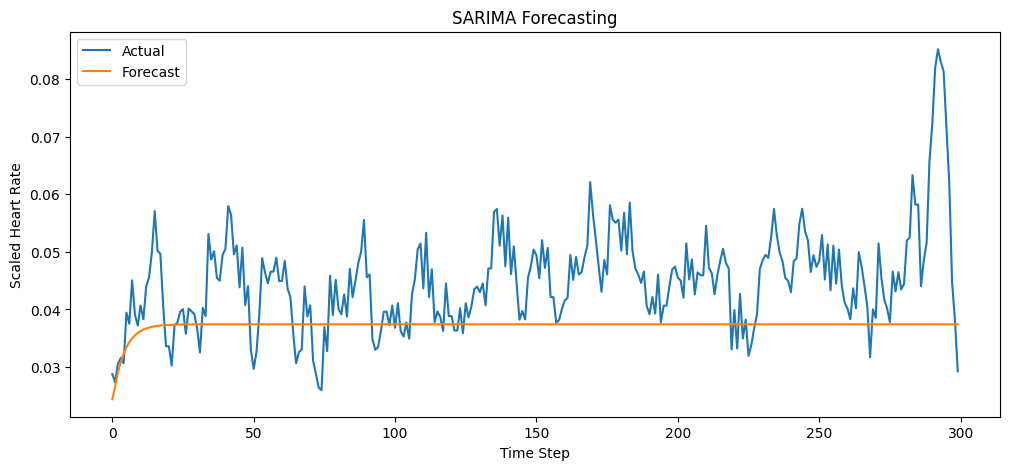

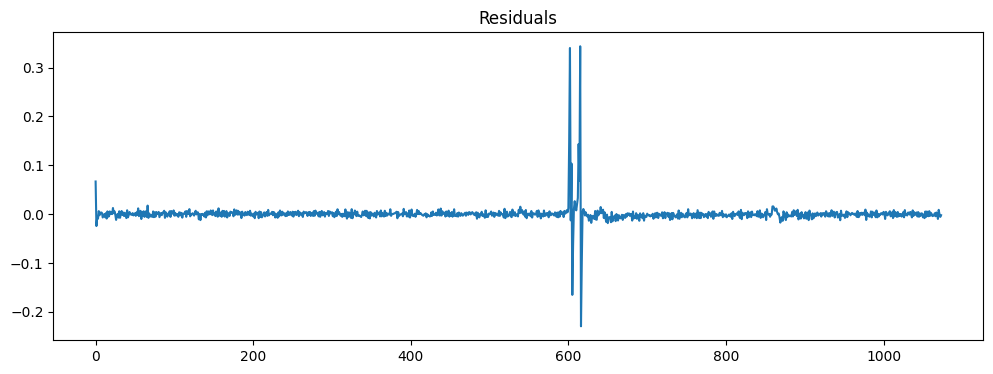

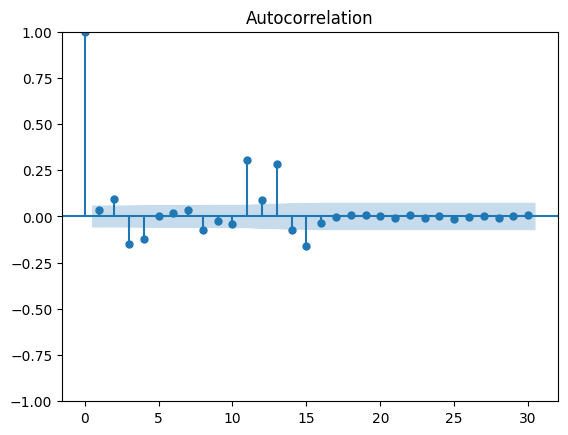

      lb_stat     lb_pvalue
10  60.243987  3.258693e-09


In [20]:
# visualization
plt.figure(figsize=(12,5))
plt.plot(
    test[:300],
    label='Actual'
)
plt.plot(
    forecast[:300],
    label='Forecast'
)
plt.title(
    'SARIMA Forecasting'
)
plt.xlabel('Time Step')
plt.ylabel('Scaled Heart Rate')
plt.legend()
plt.show()


# residual analysis
residuals = results.resid

    # Plot residuals
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title('Residuals')
plt.show()

    # ACF
plot_acf(
    residuals,
    lags=30
)
plt.show()

    # ljung-box test
lb_test = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)
print(lb_test)

# ML

In [22]:
window_size = 5

X = []
y = []

for i in range(len(all_hr) - window_size):

    X.append(
        all_hr[i:i+window_size]
    )

    y.append(
        all_hr[i+window_size]
    )

X = np.array(X)

y = np.array(y)

print(X.shape)
print(y.shape)

(1530, 5)
(1530,)


train test spilt

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    shuffle=False,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(1071, 5)
(459, 5)


random forest

In [24]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# train
rf_model.fit(
    X_train,
    y_train
)

# predict
rf_pred = rf_model.predict(
    X_test
)

XGBoost

In [25]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

# train
xgb_model.fit(
    X_train,
    y_train
)

# predict
xgb_pred = xgb_model.predict(
    X_test
)

# DL

LSTM

reshape data

In [26]:
X_train_lstm = X_train.reshape(

    X_train.shape[0],

    X_train.shape[1],

    1
)

X_test_lstm = X_test.reshape(

    X_test.shape[0],

    X_test.shape[1],

    1
)

In [29]:
lstm_model = Sequential()

# First LSTM layer
lstm_model.add(

    LSTM(

        64,

        return_sequences=True,

        input_shape=(
            X_train_lstm.shape[1],
            1
        )
    )
)

# Dropout
lstm_model.add(
    Dropout(0.2)
)

# Second LSTM layer
lstm_model.add(
    LSTM(32)
)

# Output layer
lstm_model.add(
    Dense(1)
)

# compile
lstm_model.compile(

    optimizer='adam',

    loss='mse'
)

early stopping

In [30]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True
)

In [31]:
# train
history = lstm_model.fit(

    X_train_lstm,

    y_train,

    epochs=20,

    batch_size=32,

    validation_split=0.2,

    callbacks=[early_stop]
)

# predict
lstm_pred = lstm_model.predict(
    X_test_lstm
)

lstm_pred = lstm_pred.flatten()

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0045 - val_loss: 3.9206e-04
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0038 - val_loss: 3.6909e-04
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 - val_loss: 2.0574e-04
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0035 - val_loss: 4.9343e-04
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0034 - val_loss: 1.8960e-04
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0032 - val_loss: 2.0652e-04
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0029 - val_loss: 3.2673e-04
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026 - val_loss: 1.5873e-04
Epoch 9/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0024 - val_loss: 1.3903e-04
Epoch 10/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0023 - val_loss: 1.2120e-04
Epoch 11/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0020 - val_loss: 1.0530e-04
Epoch 12/20
27/27 ━━━━━━━

In [32]:
# evaluation function
def evaluate_model(

    y_true,

    y_pred,

    model_name
):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(f"\n{model_name}")

    print(f"RMSE: {rmse:.6f}")

    print(f"MAE : {mae:.6f}")

    print(f"R2  : {r2:.6f}")

    return rmse, mae, r2

# evaluation all models
rf_metrics = evaluate_model(
    y_test,
    rf_pred,
    "Random Forest"
)

xgb_metrics = evaluate_model(
    y_test,
    xgb_pred,
    "XGBoost"
)

lstm_metrics = evaluate_model(
    y_test,
    lstm_pred,
    "LSTM"
)


Random Forest
RMSE: 0.005263
MAE : 0.004026
R2  : 0.583501

XGBoost
RMSE: 0.005569
MAE : 0.003893
R2  : 0.533674

LSTM
RMSE: 0.006507
MAE : 0.005135
R2  : 0.363213


# comparation

In [33]:
results = pd.DataFrame({

    'Model': [
        'Random Forest',
        'XGBoost',
        'LSTM'
    ],

    'RMSE': [
        rf_metrics[0],
        xgb_metrics[0],
        lstm_metrics[0]
    ],

    'MAE': [
        rf_metrics[1],
        xgb_metrics[1],
        lstm_metrics[1]
    ],

    'R2': [
        rf_metrics[2],
        xgb_metrics[2],
        lstm_metrics[2]
    ]
})

print(results)

           Model      RMSE       MAE        R2
0  Random Forest  0.005263  0.004026  0.583501
1        XGBoost  0.005569  0.003893  0.533674
2           LSTM  0.006507  0.005135  0.363213


forecast visualization

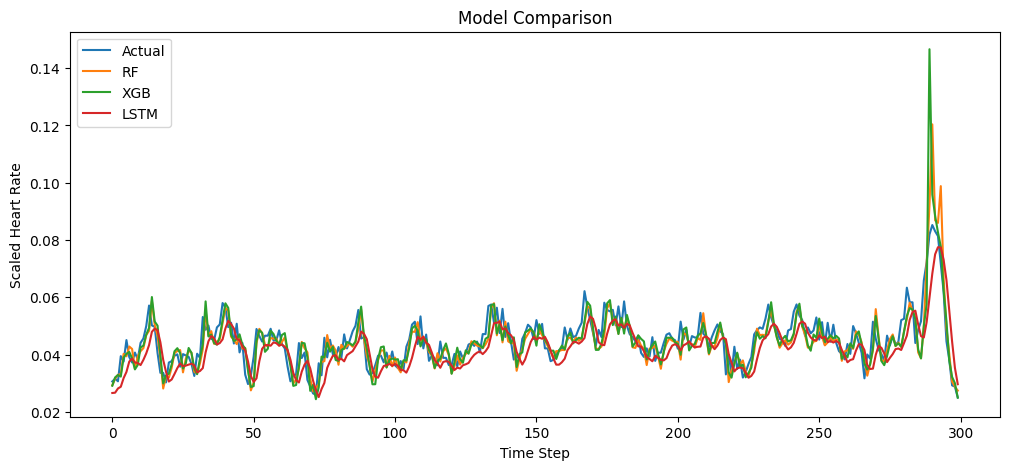

In [34]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test[:300],
    label='Actual'
)

plt.plot(
    rf_pred[:300],
    label='RF'
)

plt.plot(
    xgb_pred[:300],
    label='XGB'
)

plt.plot(
    lstm_pred[:300],
    label='LSTM'
)

plt.title(
    'Model Comparison'
)

plt.xlabel('Time Step')

plt.ylabel('Scaled Heart Rate')

plt.legend()

plt.show()

# XAI

In [35]:
importance = rf_model.feature_importances_

feature_names = [

    f't-{window_size-i}'

    for i in range(window_size)
]

importance_df = pd.DataFrame({

    'Feature': feature_names,

    'Importance': importance
})

importance_df = importance_df.sort_values(

    by='Importance',

    ascending=False
)

print(importance_df)

  Feature  Importance
4     t-1    0.877639
3     t-2    0.034389
2     t-3    0.032877
0     t-5    0.027738
1     t-4    0.027356


plot feature importance

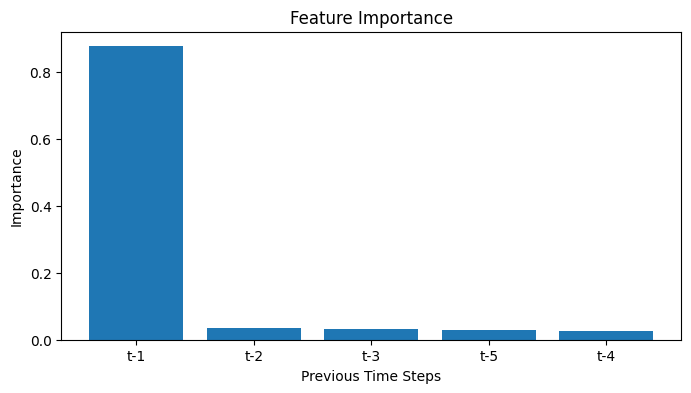

In [36]:
plt.figure(figsize=(8,4))

plt.bar(

    importance_df['Feature'],

    importance_df['Importance']
)

plt.title(
    'Feature Importance'
)

plt.xlabel(
    'Previous Time Steps'
)

plt.ylabel(
    'Importance'
)

plt.show()